Import packages

In [12]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

from scipy.stats import pearsonr # Correlation

Import file

In [11]:

df = pl.read_parquet(f'../Experiment/Knee/data/interim/2.1-train.parquet')
df.shape

(94550, 46)

In [112]:
df.dtypes

[Float64,
 Float64,
 Float64,
 Float64,
 Int64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64]

In [17]:
df = df.with_columns([
    pl.col(col).cast(pl.Float64, strict=False)
    for col in df.columns
])

c:\Users\jkrin\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jkrin\.pyenv\pyenv-win\versions\3.12.2\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: >

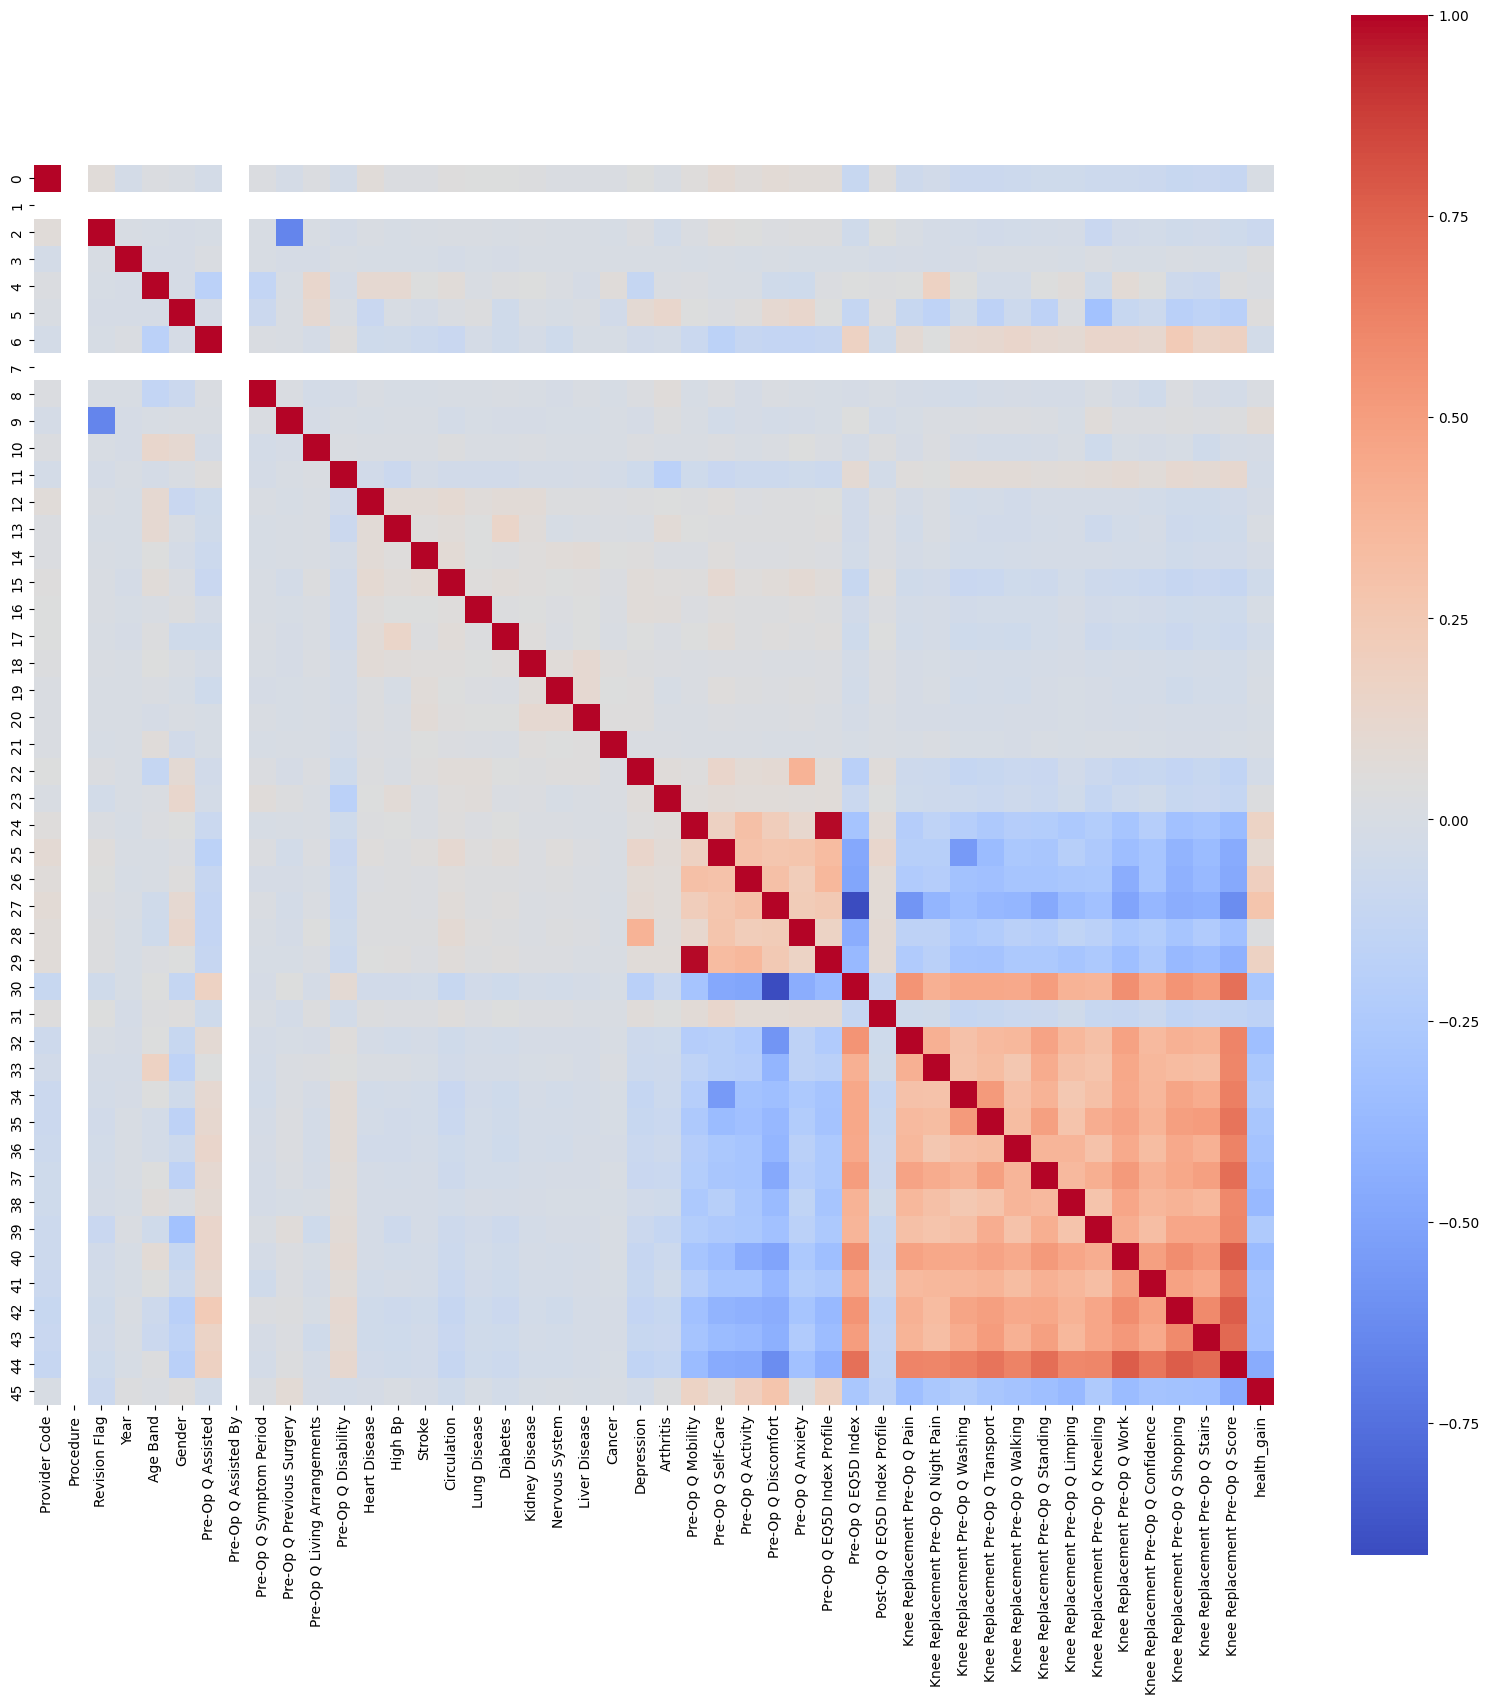

In [20]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm'
)


In [26]:
target = "health_gain"

numeric_features = (
    df
    .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))
    .columns
)

corr_overview = df.select([
    pl.corr(pl.col(target), pl.col(feature)).alias(feature)
    for feature in numeric_features
]).transpose(include_header=True, header_name="feature", column_names=["correlation"])

corr_overview = corr_overview.sort("correlation", descending=True)

corr_overview.show(50)

print(corr_overview)




C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\1806118479.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))


feature,correlation
str,f64
"""Procedure""",NaN
"""Pre-Op Q Assisted By""",NaN
"""Pre-Op Q Discomfort""",0.279532
"""Pre-Op Q Activity""",0.194373
"""Pre-Op Q EQ5D Index Profile""",0.177077
"""Pre-Op Q Mobility""",0.16568
"""Pre-Op Q Self-Care""",0.097119
"""Pre-Op Q Previous Surgery""",0.083312
"""Gender""",0.04621


shape: (45, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ correlation │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ Procedure                       ┆ NaN         │
│ Pre-Op Q Assisted By            ┆ NaN         │
│ Pre-Op Q Discomfort             ┆ 0.279532    │
│ Pre-Op Q Activity               ┆ 0.194373    │
│ Pre-Op Q EQ5D Index Profile     ┆ 0.177077    │
│ …                               ┆ …           │
│ Knee Replacement Pre-Op Q Pain  ┆ -0.331178   │
│ Knee Replacement Pre-Op Q Stan… ┆ -0.334769   │
│ Knee Replacement Pre-Op Q Work  ┆ -0.359516   │
│ Knee Replacement Pre-Op Q Limp… ┆ -0.371028   │
│ Knee Replacement Pre-Op Q Scor… ┆ -0.453938   │
└─────────────────────────────────┴─────────────┘


In [33]:
low_corr_cols = [
    "Gender",
    "Pre-Op Q Anxiety",
    "Arthritis",
    "Year",
    "Age Band",
    "Pre-Op Q Symptom Period",
    "High Bp",
    "Provider Code",
    "Cancer",
    "Nervous System",
    "Lung Disease",
    "Liver Disease",
    "Kidney Disease",
    "Stroke",
    "Pre-Op Q Living Arrangements",
    "Heart Disease",
    "Pre-Op Q Disability",
    "Depression",
    "Diabetes",
    "Pre-Op Q Assisted",
    "Circulation",
    "Revision Flag",
    "Post-Op Q EQ5D Index Profile",
    "Pre-Op Q Self-Care",	
    "Pre-Op Q Previous Surgery", 
     "Procedure",
     "Pre-Op Q Assisted By"  
]


df_reduced = df.drop(low_corr_cols)

df_reduced.columns



['Pre-Op Q Mobility',
 'Pre-Op Q Activity',
 'Pre-Op Q Discomfort',
 'Pre-Op Q EQ5D Index Profile',
 'Pre-Op Q EQ5D Index',
 'Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q Confidence',
 'Knee Replacement Pre-Op Q Shopping',
 'Knee Replacement Pre-Op Q Stairs',
 'Knee Replacement Pre-Op Q Score',
 'health_gain']

Step 1. Create a correlation matrics of the possible predicters and the outcome variable

<Axes: >

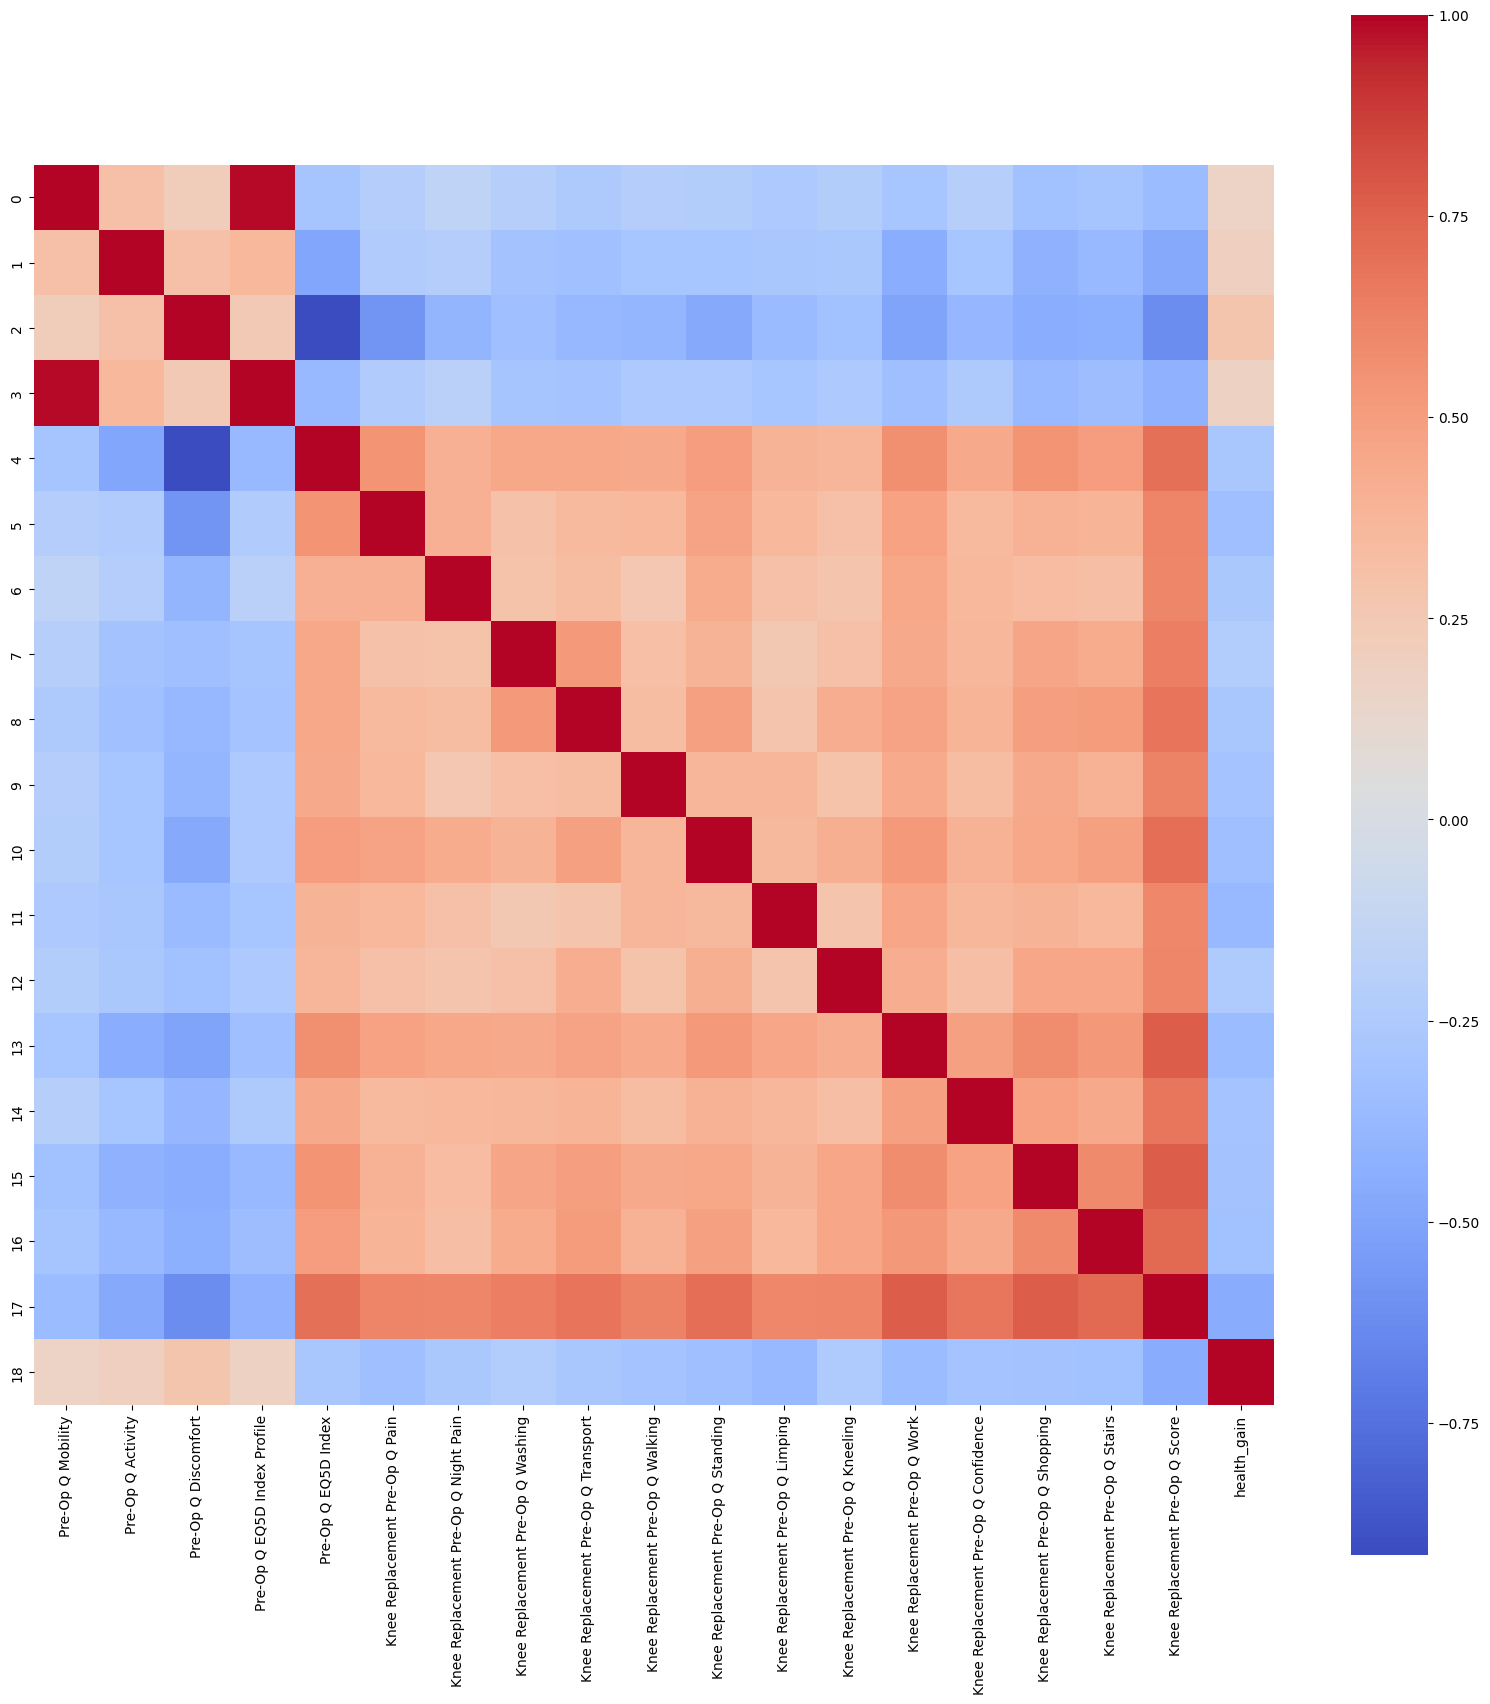

In [ ]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_reduced.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm'
)

In [37]:
target = "health_gain"

numeric_features = (
    df_reduced
    .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))
    .columns
)

corr_overview = df.select([
    pl.corr(pl.col(target), pl.col(feature)).alias(feature)
    for feature in numeric_features
]).transpose(include_header=True, header_name="feature", column_names=["correlation"])

corr_overview = corr_overview.sort("correlation", descending=True)

corr_overview.show(50)

print(corr_overview)




C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\773840197.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))


feature,correlation
str,f64
"""Pre-Op Q Discomfort""",0.279532
"""Pre-Op Q Activity""",0.194373
"""Pre-Op Q EQ5D Index Profile""",0.177077
"""Pre-Op Q Mobility""",0.16568
"""Knee Replacement Pre-Op Q Wash…",-0.227114
"""Knee Replacement Pre-Op Q Knee…",-0.243419
"""Knee Replacement Pre-Op Q Nigh…",-0.269704
"""Pre-Op Q EQ5D Index""",-0.27412
"""Knee Replacement Pre-Op Q Tran…",-0.284349


shape: (18, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ correlation │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ Pre-Op Q Discomfort             ┆ 0.279532    │
│ Pre-Op Q Activity               ┆ 0.194373    │
│ Pre-Op Q EQ5D Index Profile     ┆ 0.177077    │
│ Pre-Op Q Mobility               ┆ 0.16568     │
│ Knee Replacement Pre-Op Q Wash… ┆ -0.227114   │
│ …                               ┆ …           │
│ Knee Replacement Pre-Op Q Pain  ┆ -0.331178   │
│ Knee Replacement Pre-Op Q Stan… ┆ -0.334769   │
│ Knee Replacement Pre-Op Q Work  ┆ -0.359516   │
│ Knee Replacement Pre-Op Q Limp… ┆ -0.371028   │
│ Knee Replacement Pre-Op Q Scor… ┆ -0.453938   │
└─────────────────────────────────┴─────────────┘


In [38]:
corrs = df_reduced.select([
    pl.corr(pl.col(target), pl.col(col)).alias(col)
    for col in df_reduced.columns
    if col != target
]).transpose(
    include_header=True,
    header_name="feature",
    column_names=["correlation"]
)

corrs

feature,correlation
str,f64
"""Pre-Op Q Mobility""",0.16568
"""Pre-Op Q Activity""",0.194373
"""Pre-Op Q Discomfort""",0.279532
"""Pre-Op Q EQ5D Index Profile""",0.177077
"""Pre-Op Q EQ5D Index""",-0.27412
…,…
"""Knee Replacement Pre-Op Q Work""",-0.359516
"""Knee Replacement Pre-Op Q Conf…",-0.306811
"""Knee Replacement Pre-Op Q Shop…",-0.314741


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

target = "health_gain"

# Prepare data
X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()
y = df_reduced[target].to_numpy()

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = model.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.24360080667853667
RMSE: 8.501439533441376
MAE: 6.754830657268947


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\4286161712.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

target = "health_gain"

# Prepare data
X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()
y = df_reduced[target].to_numpy()

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = model.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.24360080667853667
RMSE: 8.501439533441376
MAE: 6.754830657268947


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\4286161712.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  X = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()


In [40]:
feature_names = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).columns

for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef}")

print("Intercept:", model.intercept_)


Pre-Op Q Mobility: 16.133198542637064
Pre-Op Q Activity: 0.7560679142976525
Pre-Op Q Discomfort: 2.5952050737597037
Pre-Op Q EQ5D Index Profile: -0.0015798518296229532
Pre-Op Q EQ5D Index: 6.528001003002456
Knee Replacement Pre-Op Q Pain: -0.8934866835487567
Knee Replacement Pre-Op Q Night Pain: 0.33946581899100176
Knee Replacement Pre-Op Q Washing: 0.30038556261138594
Knee Replacement Pre-Op Q Transport: 0.11659054608204154
Knee Replacement Pre-Op Q Walking: -0.10372901385705442
Knee Replacement Pre-Op Q Standing: -0.23483054468805528
Knee Replacement Pre-Op Q Limping: -1.118159968677862
Knee Replacement Pre-Op Q Kneeling: 0.5140044160911621
Knee Replacement Pre-Op Q Work: -0.08183647006288279
Knee Replacement Pre-Op Q Confidence: 0.04516906299471355
Knee Replacement Pre-Op Q Shopping: 0.37953813000230996
Knee Replacement Pre-Op Q Stairs: 0.07036230243980533
Knee Replacement Pre-Op Q Score: -0.666526841625404
Intercept: 20.47991510681853


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\596584966.py:1: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  feature_names = df_reduced.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).columns


In [52]:
low_corr_cols_2 = [
    "Gender",
    "Pre-Op Q Anxiety",
    "Arthritis",
    "Year",
    "Age Band",
    "Pre-Op Q Symptom Period",
    "High Bp",
    "Provider Code",
    "Cancer",
    "Nervous System",
    "Lung Disease",
    "Liver Disease",
    "Kidney Disease",
    "Stroke",
    "Pre-Op Q Living Arrangements",
    "Heart Disease",
    "Pre-Op Q Disability",
    "Depression",
    "Diabetes",
    "Pre-Op Q Assisted",
    "Circulation",
    "Revision Flag",
    "Post-Op Q EQ5D Index Profile",
    "Pre-Op Q Self-Care",	
    "Pre-Op Q Previous Surgery", 
     "Procedure",
     "Pre-Op Q Assisted By",
     "Pre-Op Q Discomfort",
     "Pre-Op Q Activity",
     "Pre-Op Q EQ5D Index Profile",
     "Pre-Op Q Mobility",
     "Pre-Op Q EQ5D Index",
     "Knee Replacement Pre-Op Q Score"  
]


df_kneepres = df.drop(low_corr_cols_2)

df_kneepres.columns



['Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q Confidence',
 'Knee Replacement Pre-Op Q Shopping',
 'Knee Replacement Pre-Op Q Stairs',
 'health_gain']

In [53]:
numeric_features = (
    df_kneepres
    .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))
    .columns
)

corr_overview = df_kneepres.select([
    pl.corr(pl.col(target), pl.col(feature)).alias(feature)
    for feature in numeric_features
]).transpose(include_header=True, header_name="feature", column_names=["correlation"])

corr_overview = corr_overview.sort("correlation", descending=True)

corr_overview.show(50)

print(corr_overview)




C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\2081124126.py:3: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  .select(pl.col(pl.NUMERIC_DTYPES).exclude(target))


feature,correlation
str,f64
"""Knee Replacement Pre-Op Q Wash…",-0.227114
"""Knee Replacement Pre-Op Q Knee…",-0.243419
"""Knee Replacement Pre-Op Q Nigh…",-0.269704
"""Knee Replacement Pre-Op Q Tran…",-0.284349
"""Knee Replacement Pre-Op Q Walk…",-0.302965
"""Knee Replacement Pre-Op Q Conf…",-0.306811
"""Knee Replacement Pre-Op Q Shop…",-0.314741
"""Knee Replacement Pre-Op Q Stai…",-0.316102
"""Knee Replacement Pre-Op Q Pain""",-0.331178


shape: (12, 2)
┌─────────────────────────────────┬─────────────┐
│ feature                         ┆ correlation │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ Knee Replacement Pre-Op Q Wash… ┆ -0.227114   │
│ Knee Replacement Pre-Op Q Knee… ┆ -0.243419   │
│ Knee Replacement Pre-Op Q Nigh… ┆ -0.269704   │
│ Knee Replacement Pre-Op Q Tran… ┆ -0.284349   │
│ Knee Replacement Pre-Op Q Walk… ┆ -0.302965   │
│ …                               ┆ …           │
│ Knee Replacement Pre-Op Q Stai… ┆ -0.316102   │
│ Knee Replacement Pre-Op Q Pain  ┆ -0.331178   │
│ Knee Replacement Pre-Op Q Stan… ┆ -0.334769   │
│ Knee Replacement Pre-Op Q Work  ┆ -0.359516   │
│ Knee Replacement Pre-Op Q Limp… ┆ -0.371028   │
└─────────────────────────────────┴─────────────┘


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

target = "health_gain"

# Prepare data
X = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()
y = df_kneepres[target].to_numpy()

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = model.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.2305175202580978
RMSE: 8.574648176258918
MAE: 6.820028345228718


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\164972124.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  X = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude(target)).to_numpy()


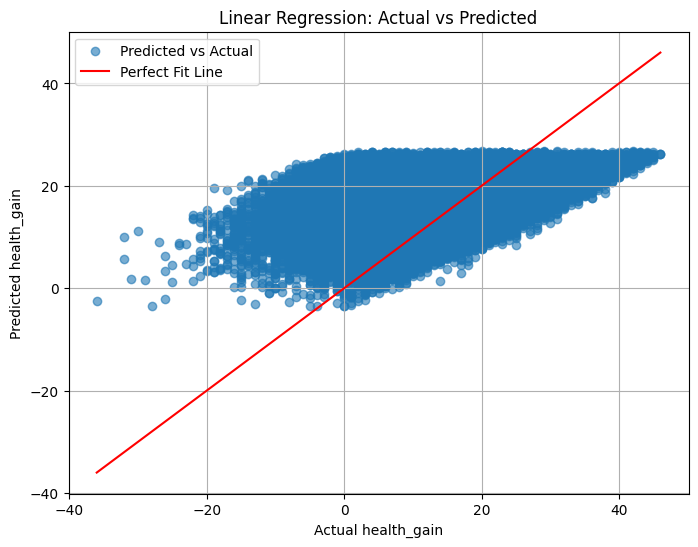

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions (model and X must already exist from your regression code)
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y, y_pred, alpha=0.6, label="Predicted vs Actual")

# Perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="Perfect Fit Line")

plt.xlabel("Actual health_gain")
plt.ylabel("Predicted health_gain")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


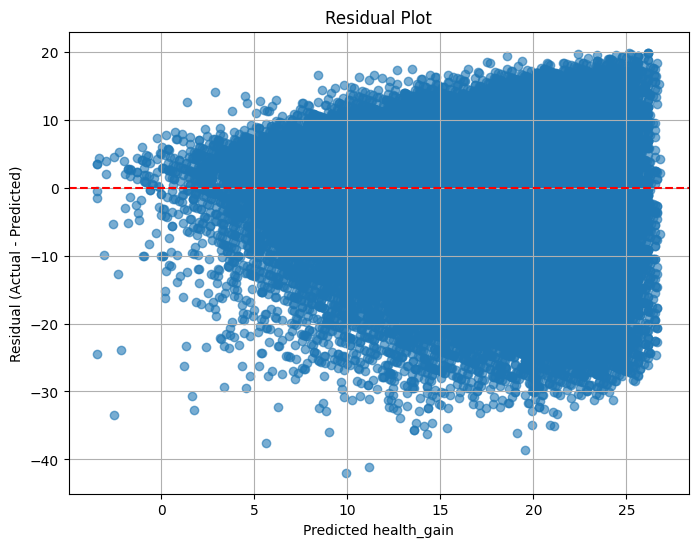

In [56]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X)

# Residuals
residuals = y - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted health_gain")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

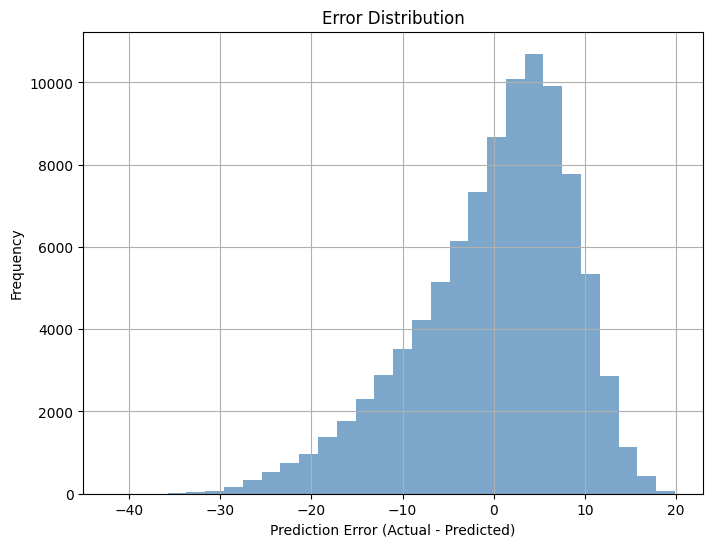

In [57]:
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X)

# Errors
errors = y - y_pred

plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, alpha=0.7, color="steelblue")

plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.grid(True)
plt.show()



What does a negative residual mean?
Residual = Actual − Predicted

So:

Negative residual → Actual < Predicted
→ The model overestimates the outcome

Positive residual → Actual > Predicted
→ The model underestimates the outcome

If your residual plot and error histogram show more negative residuals, then:

👉 Your model is systematically predicting values that are too high.
This is called systematic overprediction or bias.

C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\4009879020.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  feature_names = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")).columns


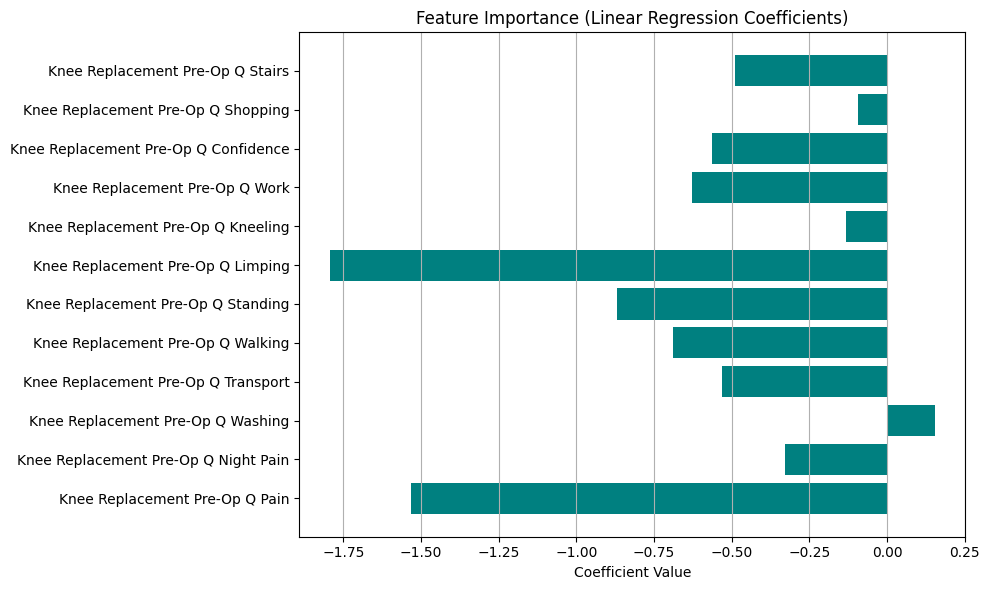

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names
feature_names = df_kneepres.select(pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")).columns

# Coefficients
coefs = model.coef_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefs, color="teal")
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()


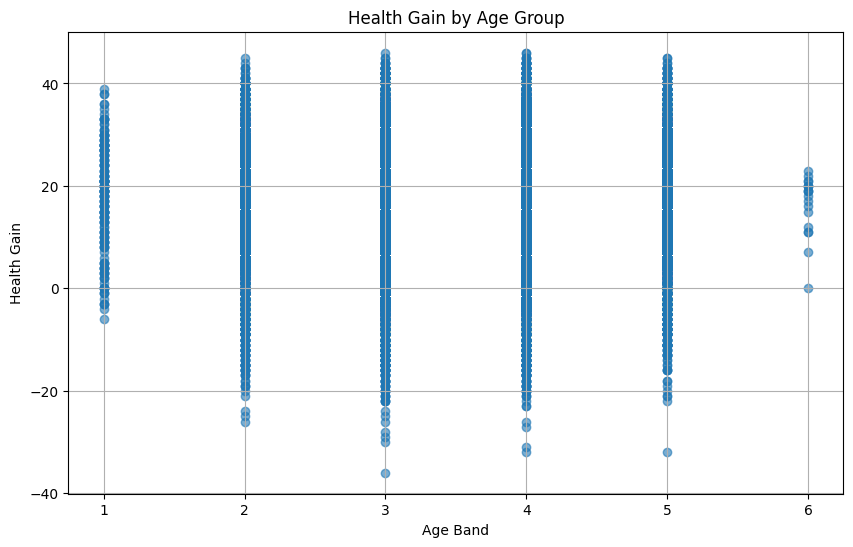

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: health_gain vs Age Band
plt.scatter(df["Age Band"], df["health_gain"], alpha=0.6)



plt.xlabel("Age Band")
plt.ylabel("Health Gain")
plt.title("Health Gain by Age Group")
plt.grid(True)
plt.show()

In [108]:
df = df.with_columns([
    pl.col("Age Band").cast(pl.Utf8),
    pl.col("health_gain").cast(pl.Float64)
])

import polars as pl

# Ensure correct types
df = df.with_columns([
    pl.col("Age Band").cast(pl.Categorical),
    pl.col("health_gain").cast(pl.Float64)
])

# Basic stats
stats = (
    df.group_by("Age Band")
      .agg([
          pl.col("health_gain").mean().alias("mean"),
          pl.col("health_gain").median().alias("median"),
          pl.col("health_gain").std().alias("std")
      ])
)

# Mode (Polars returns a list)
mode_df = (
    df.group_by("Age Band")
      .agg(pl.col("health_gain").mode().alias("mode"))
      .with_columns(pl.col("mode").list.get(0).alias("mode"))
)

# Join mode into stats
stats = stats.join(mode_df, on="Age Band")

print(stats)


# Join mode into stats
stats = stats.join(mode_df, on="Age Band")

stats = stats.sort("Age Band", descending=False)


print(stats)




shape: (6, 5)
┌──────────┬───────────┬────────┬───────────┬──────┐
│ Age Band ┆ mean      ┆ median ┆ std       ┆ mode │
│ ---      ┆ ---       ┆ ---    ┆ ---       ┆ ---  │
│ cat      ┆ f64       ┆ f64    ┆ f64       ┆ f64  │
╞══════════╪═══════════╪════════╪═══════════╪══════╡
│ 3.0      ┆ 16.925634 ┆ 18.0   ┆ 9.873397  ┆ 19.0 │
│ 5.0      ┆ 17.106143 ┆ 17.0   ┆ 9.57544   ┆ 22.0 │
│ 4.0      ┆ 17.11271  ┆ 18.0   ┆ 9.612299  ┆ 19.0 │
│ 1.0      ┆ 17.832432 ┆ 19.0   ┆ 10.316145 ┆ 21.0 │
│ 2.0      ┆ 16.569932 ┆ 17.0   ┆ 10.290489 ┆ 18.0 │
│ 6.0      ┆ 16.368421 ┆ 19.0   ┆ 5.851975  ┆ 19.0 │
└──────────┴───────────┴────────┴───────────┴──────┘
shape: (6, 6)
┌──────────┬───────────┬────────┬───────────┬──────┬────────────┐
│ Age Band ┆ mean      ┆ median ┆ std       ┆ mode ┆ mode_right │
│ ---      ┆ ---       ┆ ---    ┆ ---       ┆ ---  ┆ ---        │
│ cat      ┆ f64       ┆ f64    ┆ f64       ┆ f64  ┆ f64        │
╞══════════╪═══════════╪════════╪═══════════╪══════╪════════════╡
│ 1.0 

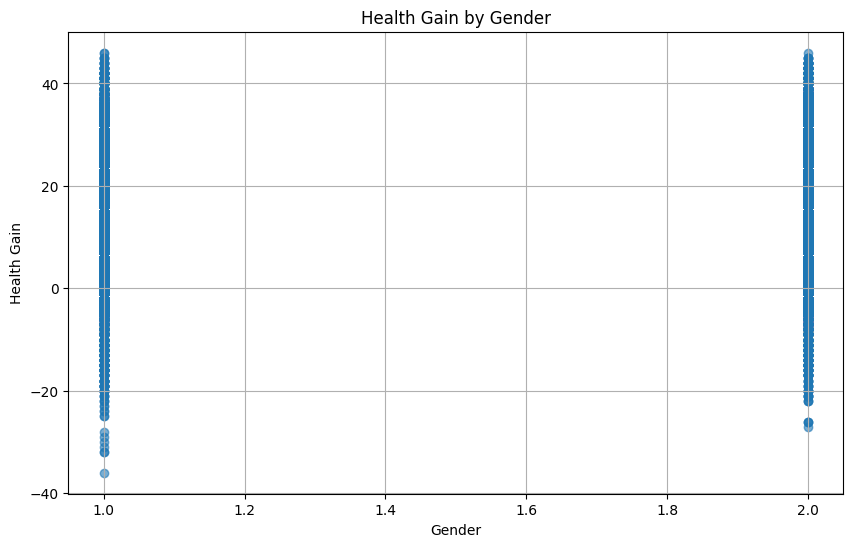

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: health_gain vs Age Band
plt.scatter(df["Gender"], df["health_gain"], alpha=0.6)



plt.xlabel("Gender")
plt.ylabel("Health Gain")
plt.title("Health Gain by Gender")
plt.grid(True)
plt.show()

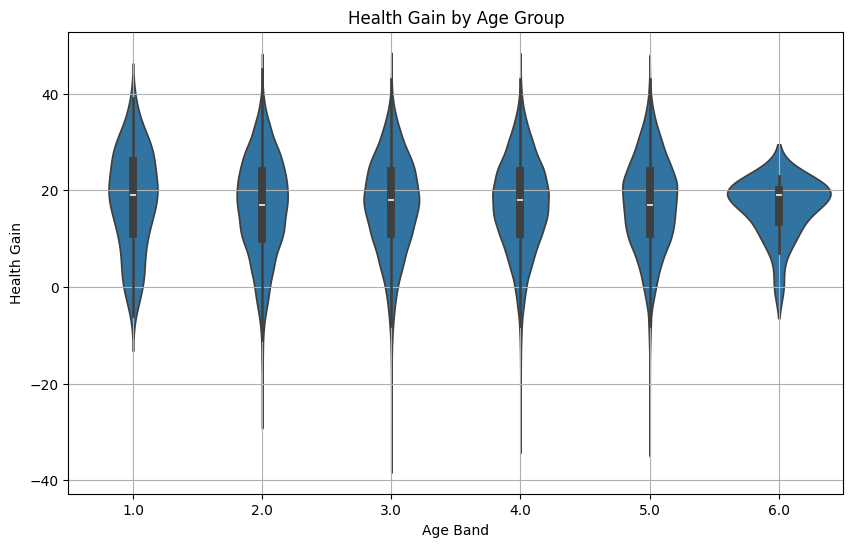

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pandas = df.to_pandas()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_pandas, x="Age Band", y="health_gain")

plt.title("Health Gain by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Health Gain")
plt.grid(True)
plt.show()


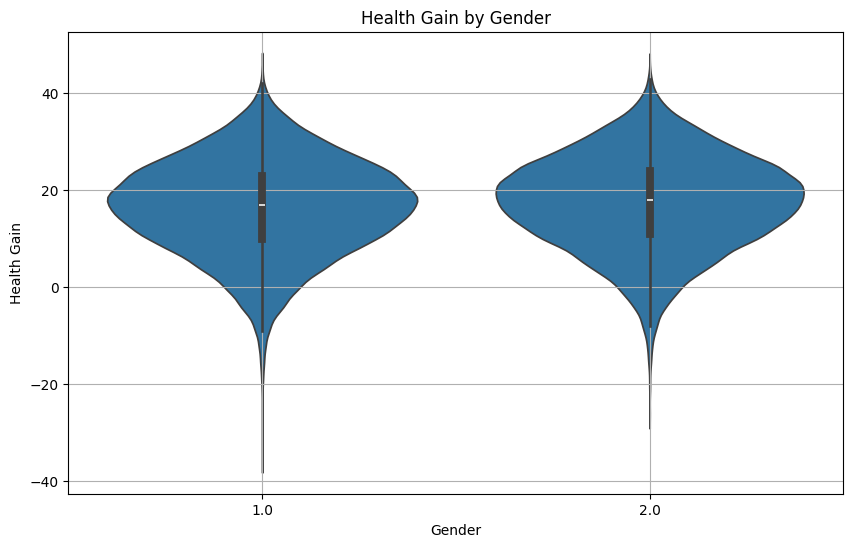

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pandas = df.to_pandas()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_pandas, x="Gender", y="health_gain")

plt.title("Health Gain by Gender")
plt.xlabel("Gender")
plt.ylabel("Health Gain")
plt.grid(True)
plt.show()

In [73]:
df["Age Band"].value_counts()


Age Band,count
f64,u32
5.0,11183
6.0,19
3.0,33362
1.0,185
2.0,9831
4.0,39970


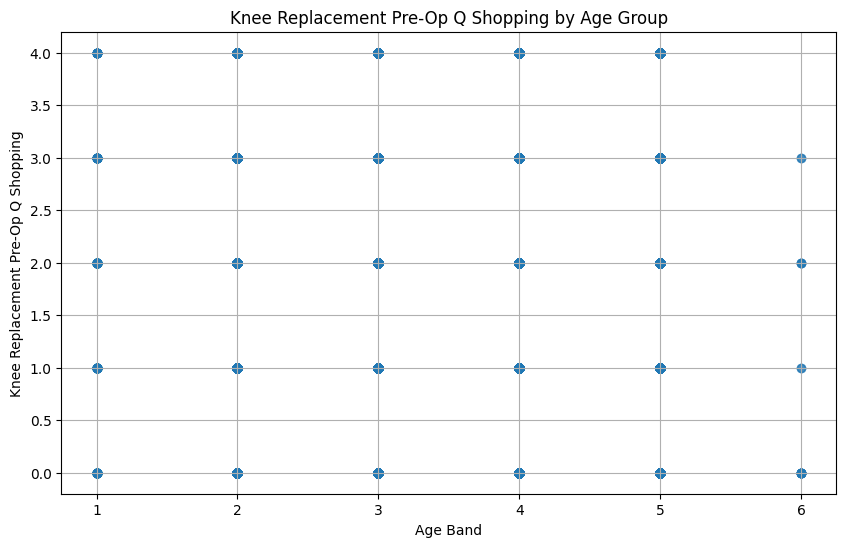

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Scatter plot: health_gain vs Age Band
plt.scatter(df["Age Band"], df["Knee Replacement Pre-Op Q Shopping"], alpha=0.6)



plt.xlabel("Age Band")
plt.ylabel("Knee Replacement Pre-Op Q Shopping")
plt.title("Knee Replacement Pre-Op Q Shopping by Age Group")
plt.grid(True)
plt.show()

In [78]:
df.select([
    pl.col("Age Band"),
    pl.col("Knee Replacement Pre-Op Q Shopping")
]).group_by(["Age Band", "Knee Replacement Pre-Op Q Shopping"]).count().sort(["Age Band"])

pl.Config.set_tbl_rows(50)   # show up to 50 rows

df.group_by(["Age Band", "Knee Replacement Pre-Op Q Shopping"]) \
  .count() \
  .sort(["Age Band", "Knee Replacement Pre-Op Q Shopping"])



C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\25615452.py:4: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  ]).group_by(["Age Band", "Knee Replacement Pre-Op Q Shopping"]).count().sort(["Age Band"])
C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\25615452.py:9: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count() \


Age Band,Knee Replacement Pre-Op Q Shopping,count
f64,f64,u32
1.0,0.0,45
1.0,1.0,43
1.0,2.0,52
1.0,3.0,29
1.0,4.0,16
2.0,0.0,1577
2.0,1.0,2100
2.0,2.0,3283
2.0,3.0,1907


In [82]:
from sklearn.linear_model import LassoCV
import polars as pl
import numpy as np


# 2. Select numeric predictors (excluding the outcome)
X = df_kneepres.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
).to_numpy()

# 3. Outcome variable
y = df_kneepres["health_gain"].to_numpy()

# 4. Fit Lasso with cross-validation to find best alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

# 5. Print results
print("Best alpha (regularization strength):", lasso.alpha_)

feature_names = df_kneepres.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
).columns

print("\nLasso Coefficients:")
for name, coef in zip(feature_names, lasso.coef_):
    print(f"{name}: {coef:.2f}")


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\2915526778.py:8: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


Best alpha (regularization strength): 0.0037100008697157406

Lasso Coefficients:
Knee Replacement Pre-Op Q Pain: -1.53
Knee Replacement Pre-Op Q Night Pain: -0.33
Knee Replacement Pre-Op Q Washing: 0.14
Knee Replacement Pre-Op Q Transport: -0.52
Knee Replacement Pre-Op Q Walking: -0.69
Knee Replacement Pre-Op Q Standing: -0.87
Knee Replacement Pre-Op Q Limping: -1.79
Knee Replacement Pre-Op Q Kneeling: -0.13
Knee Replacement Pre-Op Q Work: -0.63
Knee Replacement Pre-Op Q Confidence: -0.56
Knee Replacement Pre-Op Q Shopping: -0.10
Knee Replacement Pre-Op Q Stairs: -0.49


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\2915526778.py:22: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\483906263.py:7: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


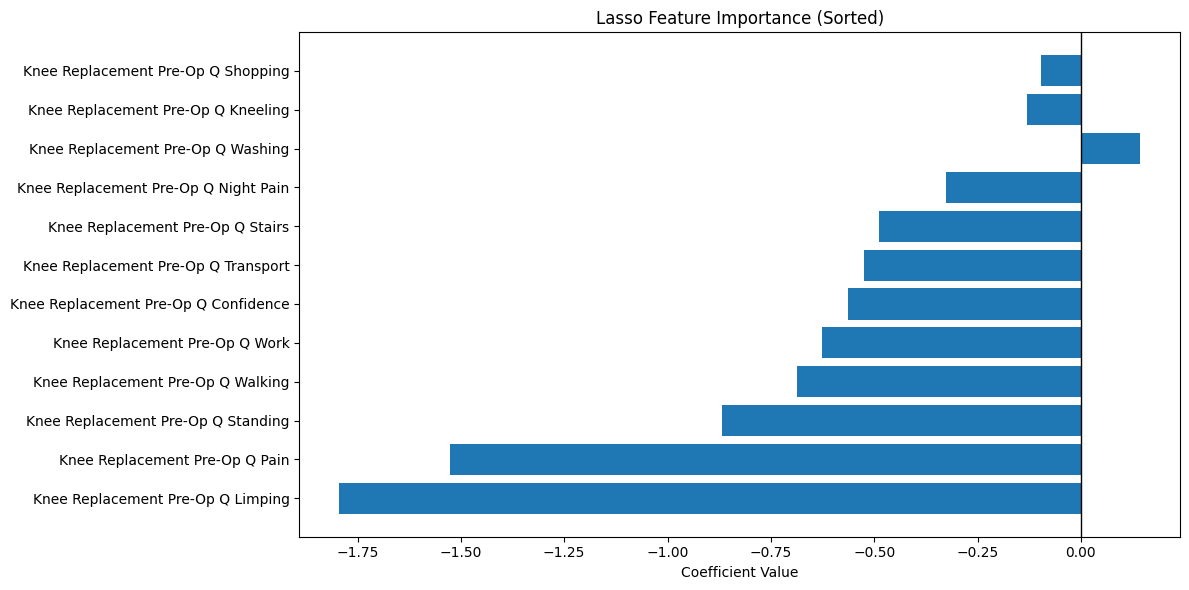

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Feature names
feature_names = np.array(
    df_kneepres.select(
        pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
    ).columns
)

coefs = np.array(lasso.coef_)

# Sort by absolute coefficient value
idx = np.argsort(np.abs(coefs))[::-1]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[idx], coefs[idx])
plt.xlabel("Coefficient Value")
plt.title("Lasso Feature Importance (Sorted)")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


<Axes: >

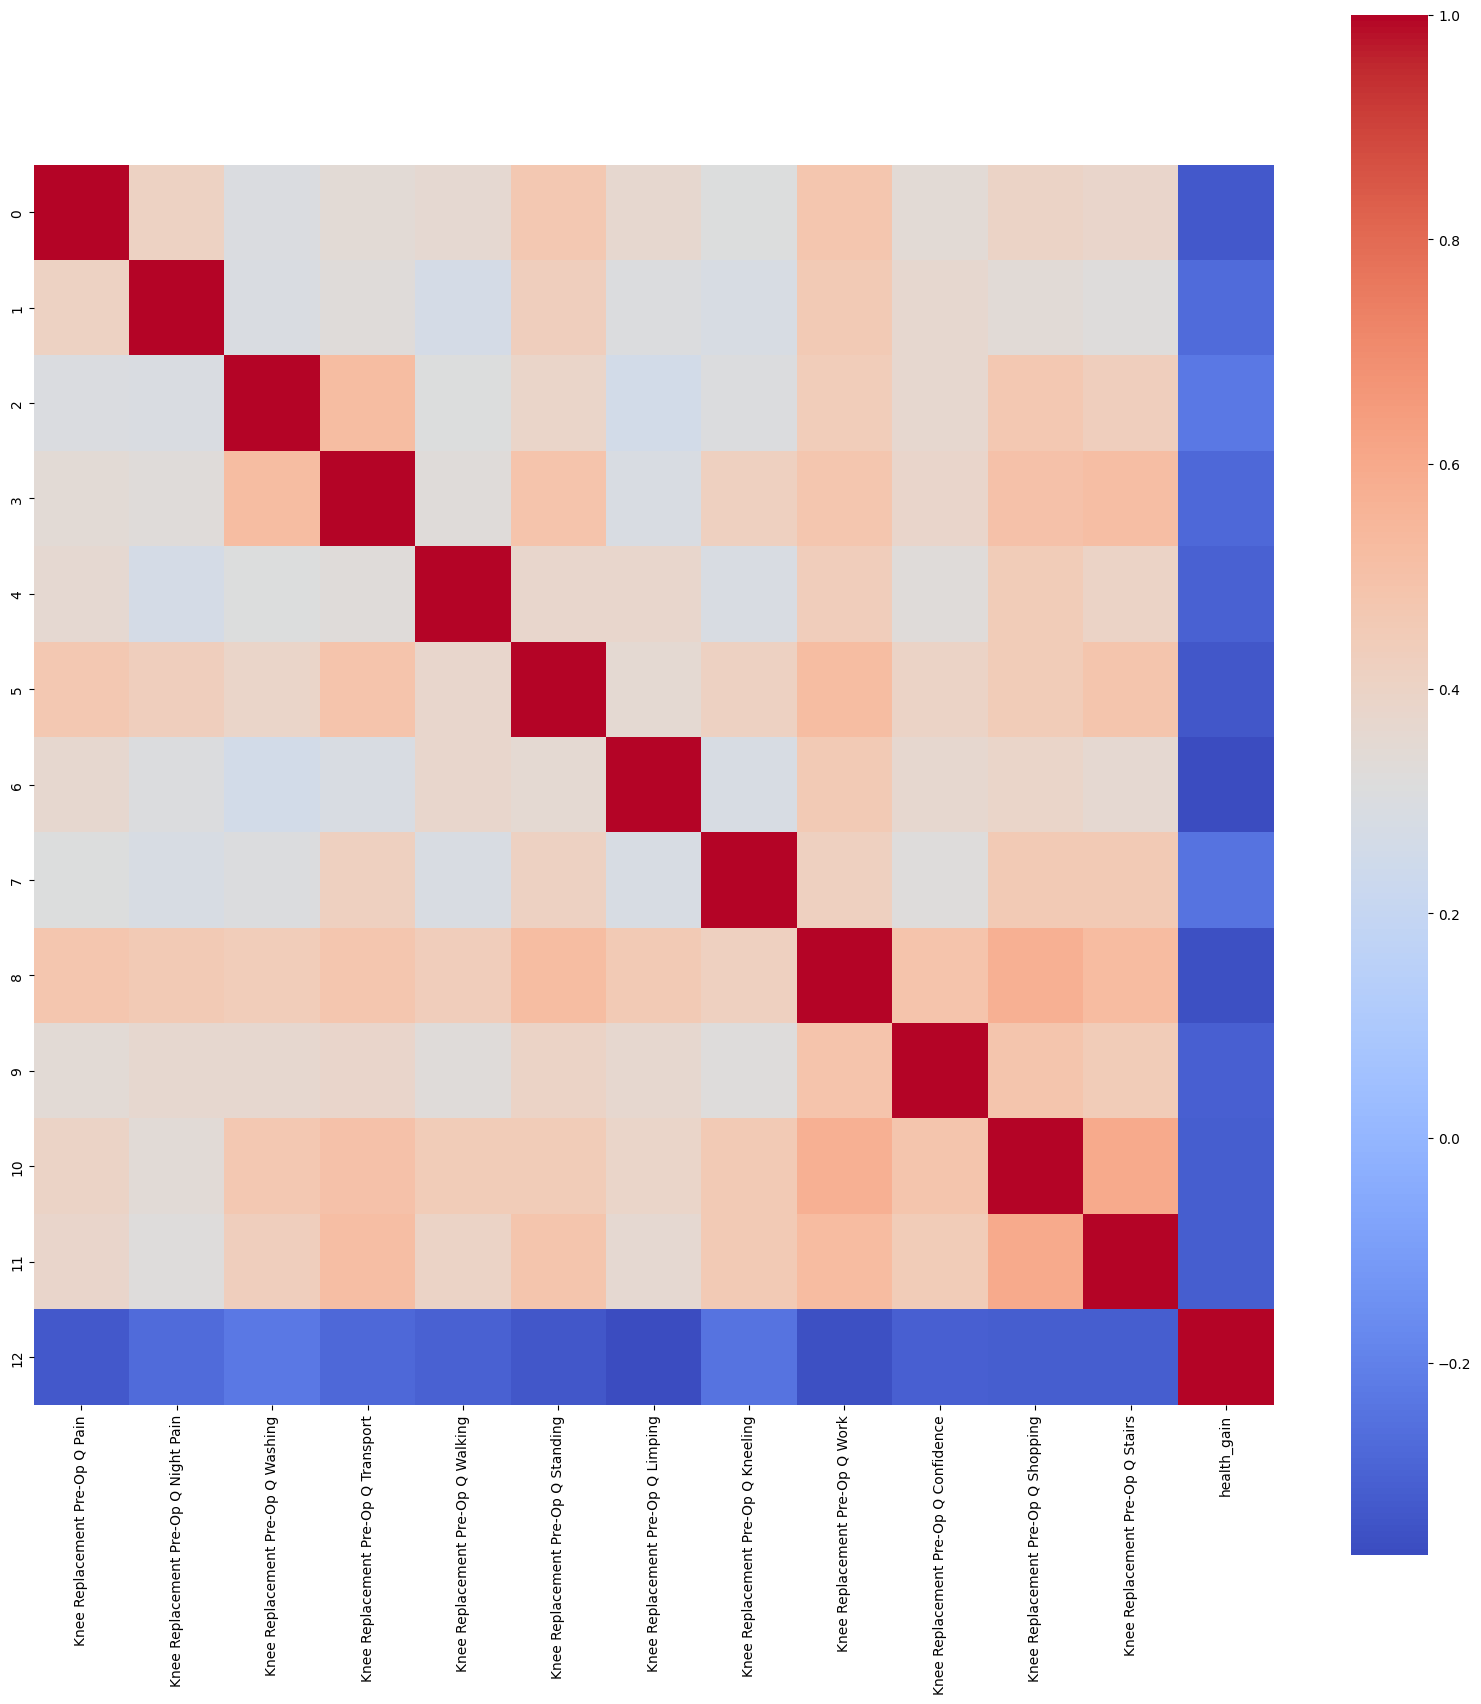

In [87]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_kneepres.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_matrix.to_pandas(),
    annot=False,
    square=True,
    cmap='coolwarm'
)

In [91]:
from sklearn.preprocessing import StandardScaler
import polars as pl
import numpy as np

# 1. Select numeric predictors (excluding the outcome)
X_df = df.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
)

# 2. Convert to numpy for scaling
X = X_df.to_numpy()

# 3. Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Outcome variable (not scaled)
y = df["health_gain"].to_numpy()

# 5. Rebuild a standardized dataframe (optional but useful)
df_standardized = pl.DataFrame(
    X_scaled,
    schema=X_df.columns
).with_columns(
    pl.Series("health_gain", y)
)


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\1169873529.py:7: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


In [92]:
from sklearn.linear_model import LassoCV

# Select predictors again (now standardized)
X = df_standardized.select(
    pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
).to_numpy()

y = df_standardized["health_gain"].to_numpy()

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)

print("Best alpha:", lasso.alpha_)



C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\3963991133.py:5: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


Best alpha: 0.005865782546141338


C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\157510827.py:6: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


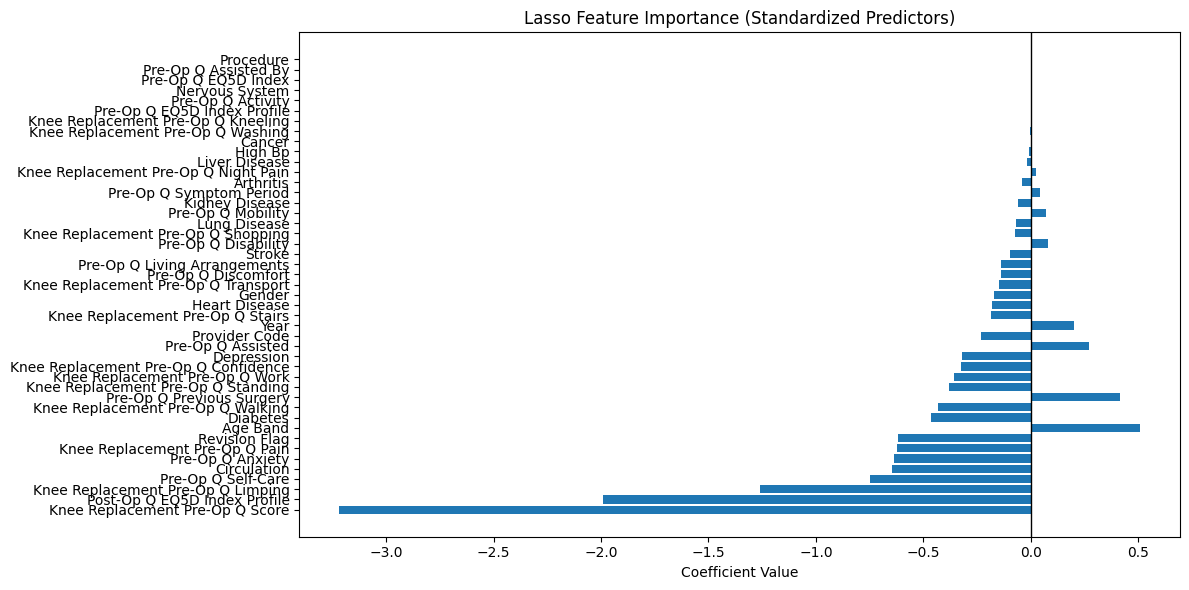

In [93]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = np.array(
    df_standardized.select(
        pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
    ).columns
)

coefs = np.array(lasso.coef_)

# Sort by absolute value
idx = np.argsort(np.abs(coefs))[::-1]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[idx], coefs[idx])
plt.xlabel("Coefficient Value")
plt.title("Lasso Feature Importance (Standardized Predictors)")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()



C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\2148666987.py:7: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")


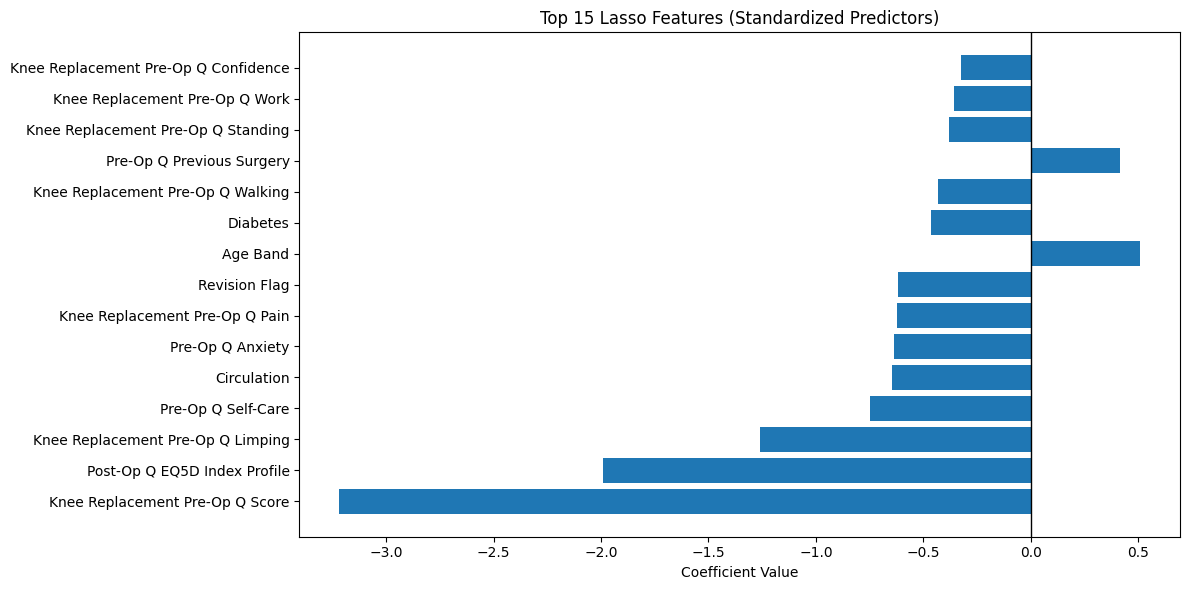

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Get feature names and coefficients
feature_names = np.array(
    df_standardized.select(
        pl.col(pl.NUMERIC_DTYPES).exclude("health_gain")
    ).columns
)
coefs = np.array(lasso.coef_)

# Sort by absolute value
idx = np.argsort(np.abs(coefs))[::-1]

# Select top 15
top_n = 15
top_idx = idx[:top_n]

plt.figure(figsize=(12, 6))
plt.barh(feature_names[top_idx], coefs[top_idx])
plt.xlabel("Coefficient Value")
plt.title("Top 15 Lasso Features (Standardized Predictors)")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()


In [109]:
import polars as pl
from scipy.stats import ttest_ind

# --- 1. Ensure correct types ---
df = df.with_columns([
    pl.col("Age Band").cast(pl.Int64),
    pl.col("health_gain").cast(pl.Float64)
])

# --- 2. T-test: group 6 vs all other groups ---

# Extract values as Python lists
group6 = df.filter(pl.col("Age Band") == 6)["health_gain"].to_list()
others = df.filter(pl.col("Age Band") != 6)["health_gain"].to_list()

# Run Welch's t-test (recommended for unequal variances)
t_stat, p_value = ttest_ind(group6, others, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# --- 3. Create dummy variables in a NEW dataframe ---

# Convert Age Band to categorical for one-hot encoding
df_dummies = df.with_columns(
    pl.col("Age Band").cast(pl.Categorical)
).to_dummies(columns=["Age Band"])

print(df_dummies)


T-statistic: nan
P-value: nan
shape: (94_550, 51)
┌────────────┬───────────┬────────────┬──────┬───┬────────────┬────────────┬───────────┬───────────┐
│ Provider   ┆ Procedure ┆ Revision   ┆ Year ┆ … ┆ Knee Repla ┆ Knee Repla ┆ Knee Repl ┆ health_ga │
│ Code       ┆ ---       ┆ Flag       ┆ ---  ┆   ┆ cement     ┆ cement     ┆ acement   ┆ in        │
│ ---        ┆ f64       ┆ ---        ┆ f64  ┆   ┆ Pre-Op Q   ┆ Pre-Op Q   ┆ Pre-Op Q  ┆ ---       │
│ f64        ┆           ┆ f64        ┆      ┆   ┆ Shop…      ┆ Stai…      ┆ Scor…     ┆ f64       │
│            ┆           ┆            ┆      ┆   ┆ ---        ┆ ---        ┆ ---       ┆           │
│            ┆           ┆            ┆      ┆   ┆ f64        ┆ f64        ┆ f64       ┆           │
╞════════════╪═══════════╪════════════╪══════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 268.0      ┆ 1.0       ┆ 0.0        ┆ 3.0  ┆ … ┆ 0.0        ┆ 0.0        ┆ 7.0       ┆ 16.0      │
│ 69.0       ┆ 1.0       ┆ 0.0        ┆ 2

C:\Users\jkrin\AppData\Local\Temp\ipykernel_26492\3665077526.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = ttest_ind(group6, others, equal_var=False)
